In [1]:
#the csvSignalTestworking script took a csv file with time and signal values, and created a csv file with time and voltage values
#next step is to implement time cuts: for each event we record with a counter we need some info
    #time of event, so that we can identify the event in the voltage csv file and cut around it
    #type of event (passby or stop) so that we know how large to make the time cut
#we want the counter to produce a file with event count and event time

In [1]:
#grab voltage csv file and define voltage array
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import time
import glob
import os

readVoltage = pd.read_csv('./output/overnight_run_apr1_voltage.csv')
readVoltage

,timecode,seconds,lat,lat_dir,lon,lon_dir,sensor,voltage
0,260401_002748_000,1668.000,4200.0068,N,8739.5635,W,28,0.008545
1,260401_002748_433,1668.433,4200.0068,N,8739.5635,W,13,0.003968
2,260401_002748_532,1668.532,4200.0068,N,8739.5635,W,11,0.003357
3,260401_002748_632,1668.632,4200.0068,N,8739.5635,W,12,0.003662
4,260401_002748_732,1668.732,4200.0068,N,8739.5635,W,11,0.003357
...,...,...,...,...,...,...,...,...
572411,260401_162215_600,58935.602,4159.9849,N,8739.4453,W,11,0.003357
572412,260401_162215_700,58935.699,4159.9849,N,8739.4453,W,11,0.003357
572413,260401_162215_800,58935.801,4159.9849,N,8739.4453,W,11,0.003357
572414,260401_162215_900,58935.898,4159.9849,N,8739.4453,W,12,0.003662


In [5]:
#same thing with the csv that has cliker data for trains passing by
readPassby0 = pd.read_csv('./testing.csv.csv')
readPassby = readPassby0 + 72940
readPassby

,events,time (seconds)
0,72941,73000
1,72942,73020
2,72943,73140
3,72944,73340
4,72945,73620
5,72946,73730
6,72947,73740
7,72948,73820
8,72949,73841
9,72950,73913


In [6]:
#Identify events in readVoltage that are also in readPassby
readVoltage['seconds'] = pd.to_numeric(readVoltage['seconds'], errors='coerce')
readPassby['seconds'] = pd.to_numeric(readPassby['time (seconds)'], errors='coerce')

readVoltage = readVoltage.dropna(subset=['seconds']).reset_index(drop=True)
readPassby = readPassby.dropna(subset=['time (seconds)']).reset_index(drop=True)

#redefine with only these times
voltage_times = readVoltage['seconds'].to_numpy()
passby_times = readPassby['time (seconds)'].to_numpy()

#make cuts - around each event, keep a range of events as it will take seconds for the train to pass
rows_before = 50
rows_after = 50
#max_time_diff = 0.1

cuts = []

for trigger_num, t_small in enumerate(passby_times):
    #for each event in the passby csv, fetch an event with the same t in the voltage csv
    match_index = np.argmin(np.abs(voltage_times - t_small))
    matched_time = voltage_times[match_index]
    time_diff = abs(matched_time - t_small)

    #if time_diff > max_time_diff:
        #continue

    start_index = max(0, match_index - rows_before)
    end_index = min(len(readVoltage), match_index + rows_after + 1)
    
    cut = readVoltage.iloc[start_index:end_index].copy()
    
    cut['trigger_num'] = trigger_num
    cut['trigger_time_small'] = t_small
    cut['matched_time_large'] = matched_time
    cut['match_time_diff'] = time_diff
    cut['relative_row'] = np.arange(start_index, end_index) - match_index
    cut['relative_time'] = cut['seconds'] - matched_time

    cuts.append(cut)

readCutvoltage = pd.concat(cuts, ignore_index=True)
readCutvoltage.to_csv('voltage_after_uno.csv', index=False)

In [7]:
voltagecutArr = np.array(readCutvoltage['sensor'])
len(voltagecutArr)

510

Text(0, 0.5, 'sensor value')

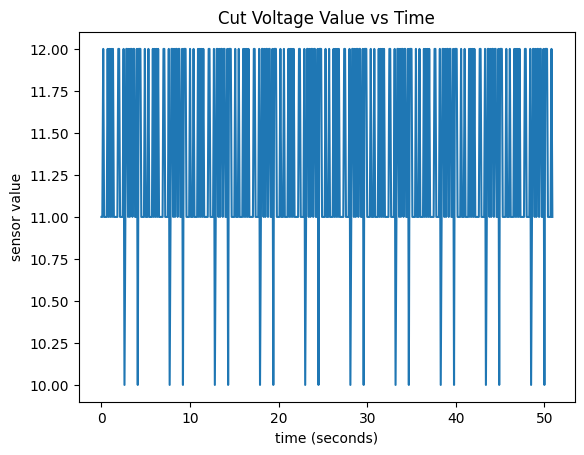

In [9]:
timeseries = np.arange(0,51.0,0.1)

plt.plot(timeseries,voltagecutArr)
plt.title('Cut Voltage Value vs Time')
plt.xlabel('time (seconds)')
plt.ylabel('sensor value')